# Exploratory Data Analysis — Credit Card Fraud Detection

**Dataset:** [Kaggle Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

284,807 credit card transactions from European cardholders (September 2013, 2 days).
Features V1–V28 are PCA-transformed (confidential originals). Only `Time` and `Amount`
are untransformed.

**Goal:** Understand the data before building fraud detection models.

## 1. Data Loading & Initial Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

In [2]:
df = pd.read_csv("../data/raw/creditcard.csv")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Shape: 284,807 rows x 31 columns


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


### Missing Values

In [5]:
missing = df.isnull().sum()
print(f"Total missing values: {missing.sum()}")
# No missing values — the PCA transformation and dataset curation ensured completeness.

Total missing values: 0


### Duplicate Rows

In [6]:
n_duplicates = df.duplicated().sum()
print(f"Duplicate rows: {n_duplicates:,} ({n_duplicates / len(df) * 100:.2f}%)")

# Check: are duplicates mostly fraud or non-fraud?
dup_mask = df.duplicated(keep=False)
print(f"\nClass distribution in duplicate rows:")
print(df[dup_mask]["Class"].value_counts())
print(f"\nClass distribution in non-duplicate rows:")
print(df[~dup_mask]["Class"].value_counts())

Duplicate rows: 1,081 (0.38%)



Class distribution in duplicate rows:
Class
0    1822
1      32
Name: count, dtype: int64

Class distribution in non-duplicate rows:
Class
0    282493
1       460
Name: count, dtype: int64


There are 1,081 duplicate rows. Since these are real transactions (different customers can
make identical-looking transactions after PCA), we'll **keep them** — dropping could
remove legitimate data points.

## 2. Class Distribution

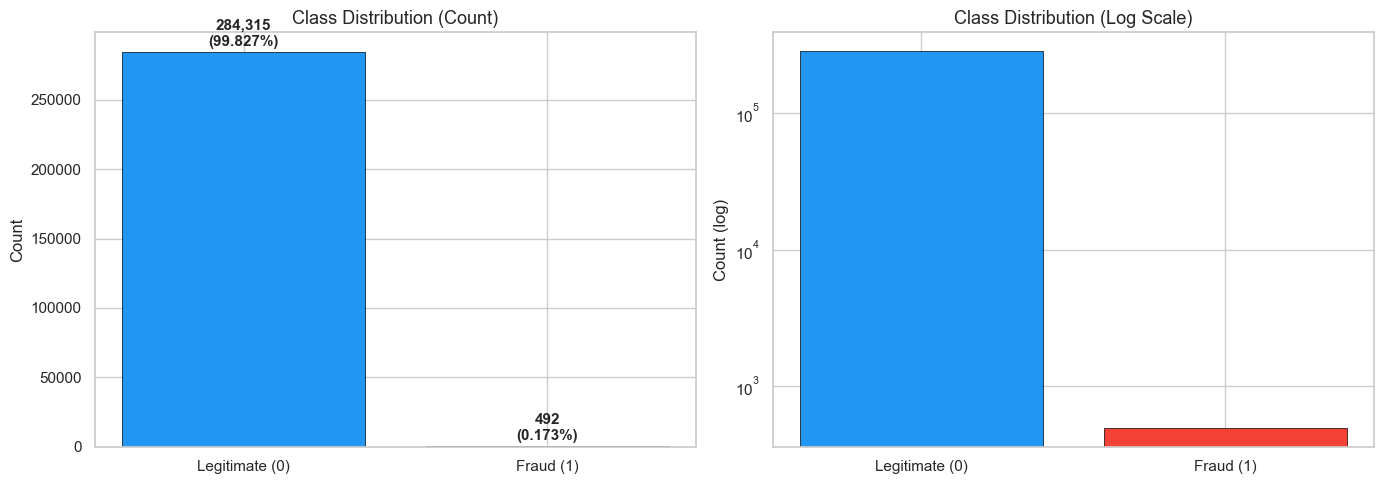


Imbalance ratio: 1 fraud per 577 legitimate transactions


In [7]:
class_counts = df["Class"].value_counts()
class_pct = df["Class"].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(
    ["Legitimate (0)", "Fraud (1)"],
    class_counts.values,
    color=["#2196F3", "#F44336"],
    edgecolor="black",
    linewidth=0.5,
)
for bar, count, pct in zip(bars, class_counts.values, class_pct.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2000,
        f"{count:,}\n({pct:.3f}%)",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )
axes[0].set_title("Class Distribution (Count)", fontsize=13)
axes[0].set_ylabel("Count")

# Log scale version to see fraud bar
axes[1].bar(
    ["Legitimate (0)", "Fraud (1)"],
    class_counts.values,
    color=["#2196F3", "#F44336"],
    edgecolor="black",
    linewidth=0.5,
)
axes[1].set_yscale("log")
axes[1].set_title("Class Distribution (Log Scale)", fontsize=13)
axes[1].set_ylabel("Count (log)")

plt.tight_layout()
plt.savefig("../data/processed/01_class_distribution.png", bbox_inches="tight")
plt.show()

print(
    f"\nImbalance ratio: 1 fraud per {class_counts[0] // class_counts[1]:,} legitimate transactions"
)

**Extreme class imbalance:** Only 0.173% of transactions are fraudulent (492 out of 284,807).
This is a 1:578 ratio. Implications:
- Accuracy is a useless metric (99.83% by predicting all legitimate)
- Must use **PR-AUC**, **F1**, **precision**, and **recall** for evaluation
- Need class balancing strategies: `scale_pos_weight`, SMOTE, or threshold tuning

## 3. Feature Distributions

### 3.1 Time

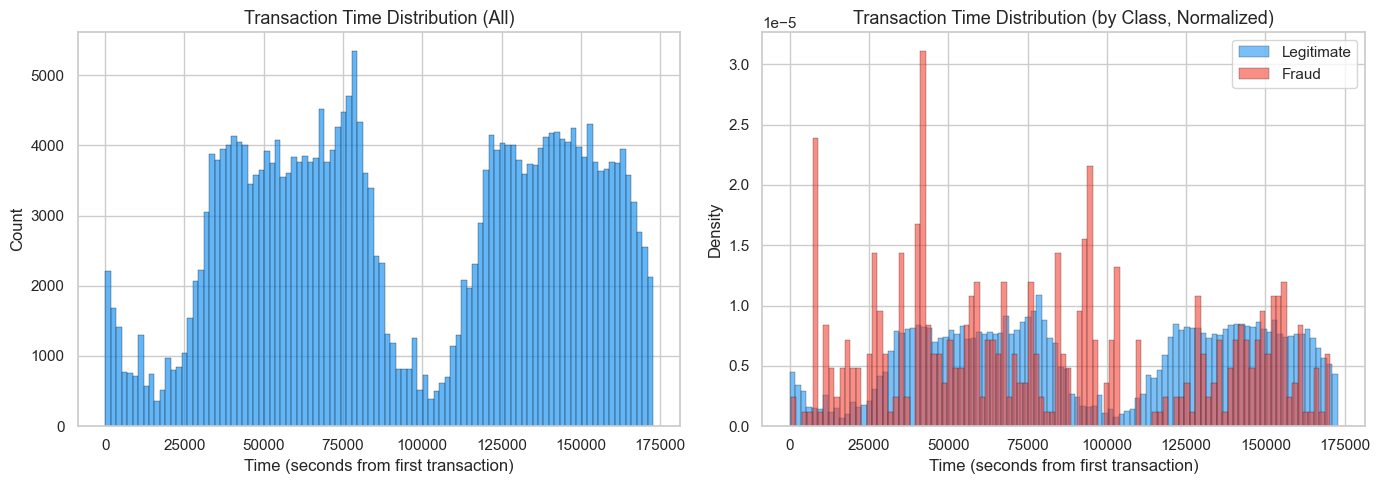

Time range: 0 to 172792 seconds
That's approximately 48.0 hours (2.0 days)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall Time distribution
axes[0].hist(
    df["Time"], bins=100, color="#2196F3", alpha=0.7, edgecolor="black", linewidth=0.3
)
axes[0].set_title("Transaction Time Distribution (All)", fontsize=13)
axes[0].set_xlabel("Time (seconds from first transaction)")
axes[0].set_ylabel("Count")

# Time by class
for cls, color, label in [(0, "#2196F3", "Legitimate"), (1, "#F44336", "Fraud")]:
    subset = df[df["Class"] == cls]["Time"]
    axes[1].hist(
        subset,
        bins=100,
        color=color,
        alpha=0.6,
        label=label,
        density=True,
        edgecolor="black",
        linewidth=0.3,
    )
axes[1].set_title("Transaction Time Distribution (by Class, Normalized)", fontsize=13)
axes[1].set_xlabel("Time (seconds from first transaction)")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.savefig("../data/processed/01_time_distribution.png", bbox_inches="tight")
plt.show()

# Time spans ~48 hours (172,792 seconds)
print(f"Time range: {df['Time'].min():.0f} to {df['Time'].max():.0f} seconds")
print(
    f"That's approximately {df['Time'].max() / 3600:.1f} hours ({df['Time'].max() / 86400:.1f} days)"
)

The Time feature shows two clear cycles (two days), with dips corresponding to nighttime.
Fraud appears more uniformly distributed across time — fraudsters don't sleep.
**Feature idea:** Extract hour-of-day as a cyclical feature.

### 3.2 Amount

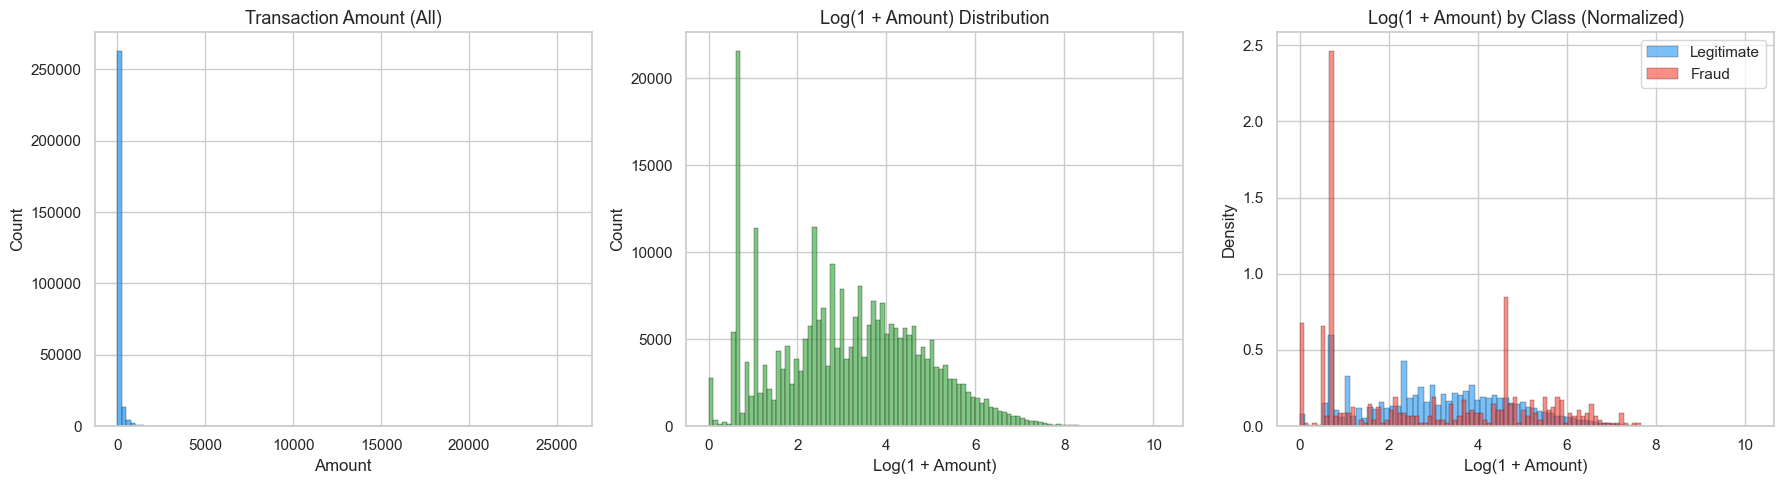

Amount statistics:
  Overall — Mean: $88.35, Median: $22.00, Max: $25691.16
  Fraud   — Mean: $122.21, Median: $9.25
  Legit   — Mean: $88.29, Median: $22.00


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Raw Amount
axes[0].hist(
    df["Amount"], bins=100, color="#2196F3", alpha=0.7, edgecolor="black", linewidth=0.3
)
axes[0].set_title("Transaction Amount (All)", fontsize=13)
axes[0].set_xlabel("Amount")
axes[0].set_ylabel("Count")

# Log Amount (for better visibility)
log_amount = np.log1p(df["Amount"])
axes[1].hist(
    log_amount, bins=100, color="#4CAF50", alpha=0.7, edgecolor="black", linewidth=0.3
)
axes[1].set_title("Log(1 + Amount) Distribution", fontsize=13)
axes[1].set_xlabel("Log(1 + Amount)")
axes[1].set_ylabel("Count")

# Amount by class
for cls, color, label in [(0, "#2196F3", "Legitimate"), (1, "#F44336", "Fraud")]:
    subset = df[df["Class"] == cls]["Amount"]
    axes[2].hist(
        np.log1p(subset),
        bins=80,
        color=color,
        alpha=0.6,
        label=label,
        density=True,
        edgecolor="black",
        linewidth=0.3,
    )
axes[2].set_title("Log(1 + Amount) by Class (Normalized)", fontsize=13)
axes[2].set_xlabel("Log(1 + Amount)")
axes[2].set_ylabel("Density")
axes[2].legend()

plt.tight_layout()
plt.savefig("../data/processed/01_amount_distribution.png", bbox_inches="tight")
plt.show()

print("Amount statistics:")
print(
    f"  Overall — Mean: ${df['Amount'].mean():.2f}, Median: ${df['Amount'].median():.2f}, Max: ${df['Amount'].max():.2f}"
)
print(
    f"  Fraud   — Mean: ${df[df['Class'] == 1]['Amount'].mean():.2f}, Median: ${df[df['Class'] == 1]['Amount'].median():.2f}"
)
print(
    f"  Legit   — Mean: ${df[df['Class'] == 0]['Amount'].mean():.2f}, Median: ${df[df['Class'] == 0]['Amount'].median():.2f}"
)

Amount is heavily right-skewed (most transactions are small). Fraudulent transactions tend
to have a **lower median** but similar mean — fraud spans a wide range of amounts.
**Feature idea:** Log-transform Amount, and possibly bin into categories.

### 3.3 V-Features (PCA Components)

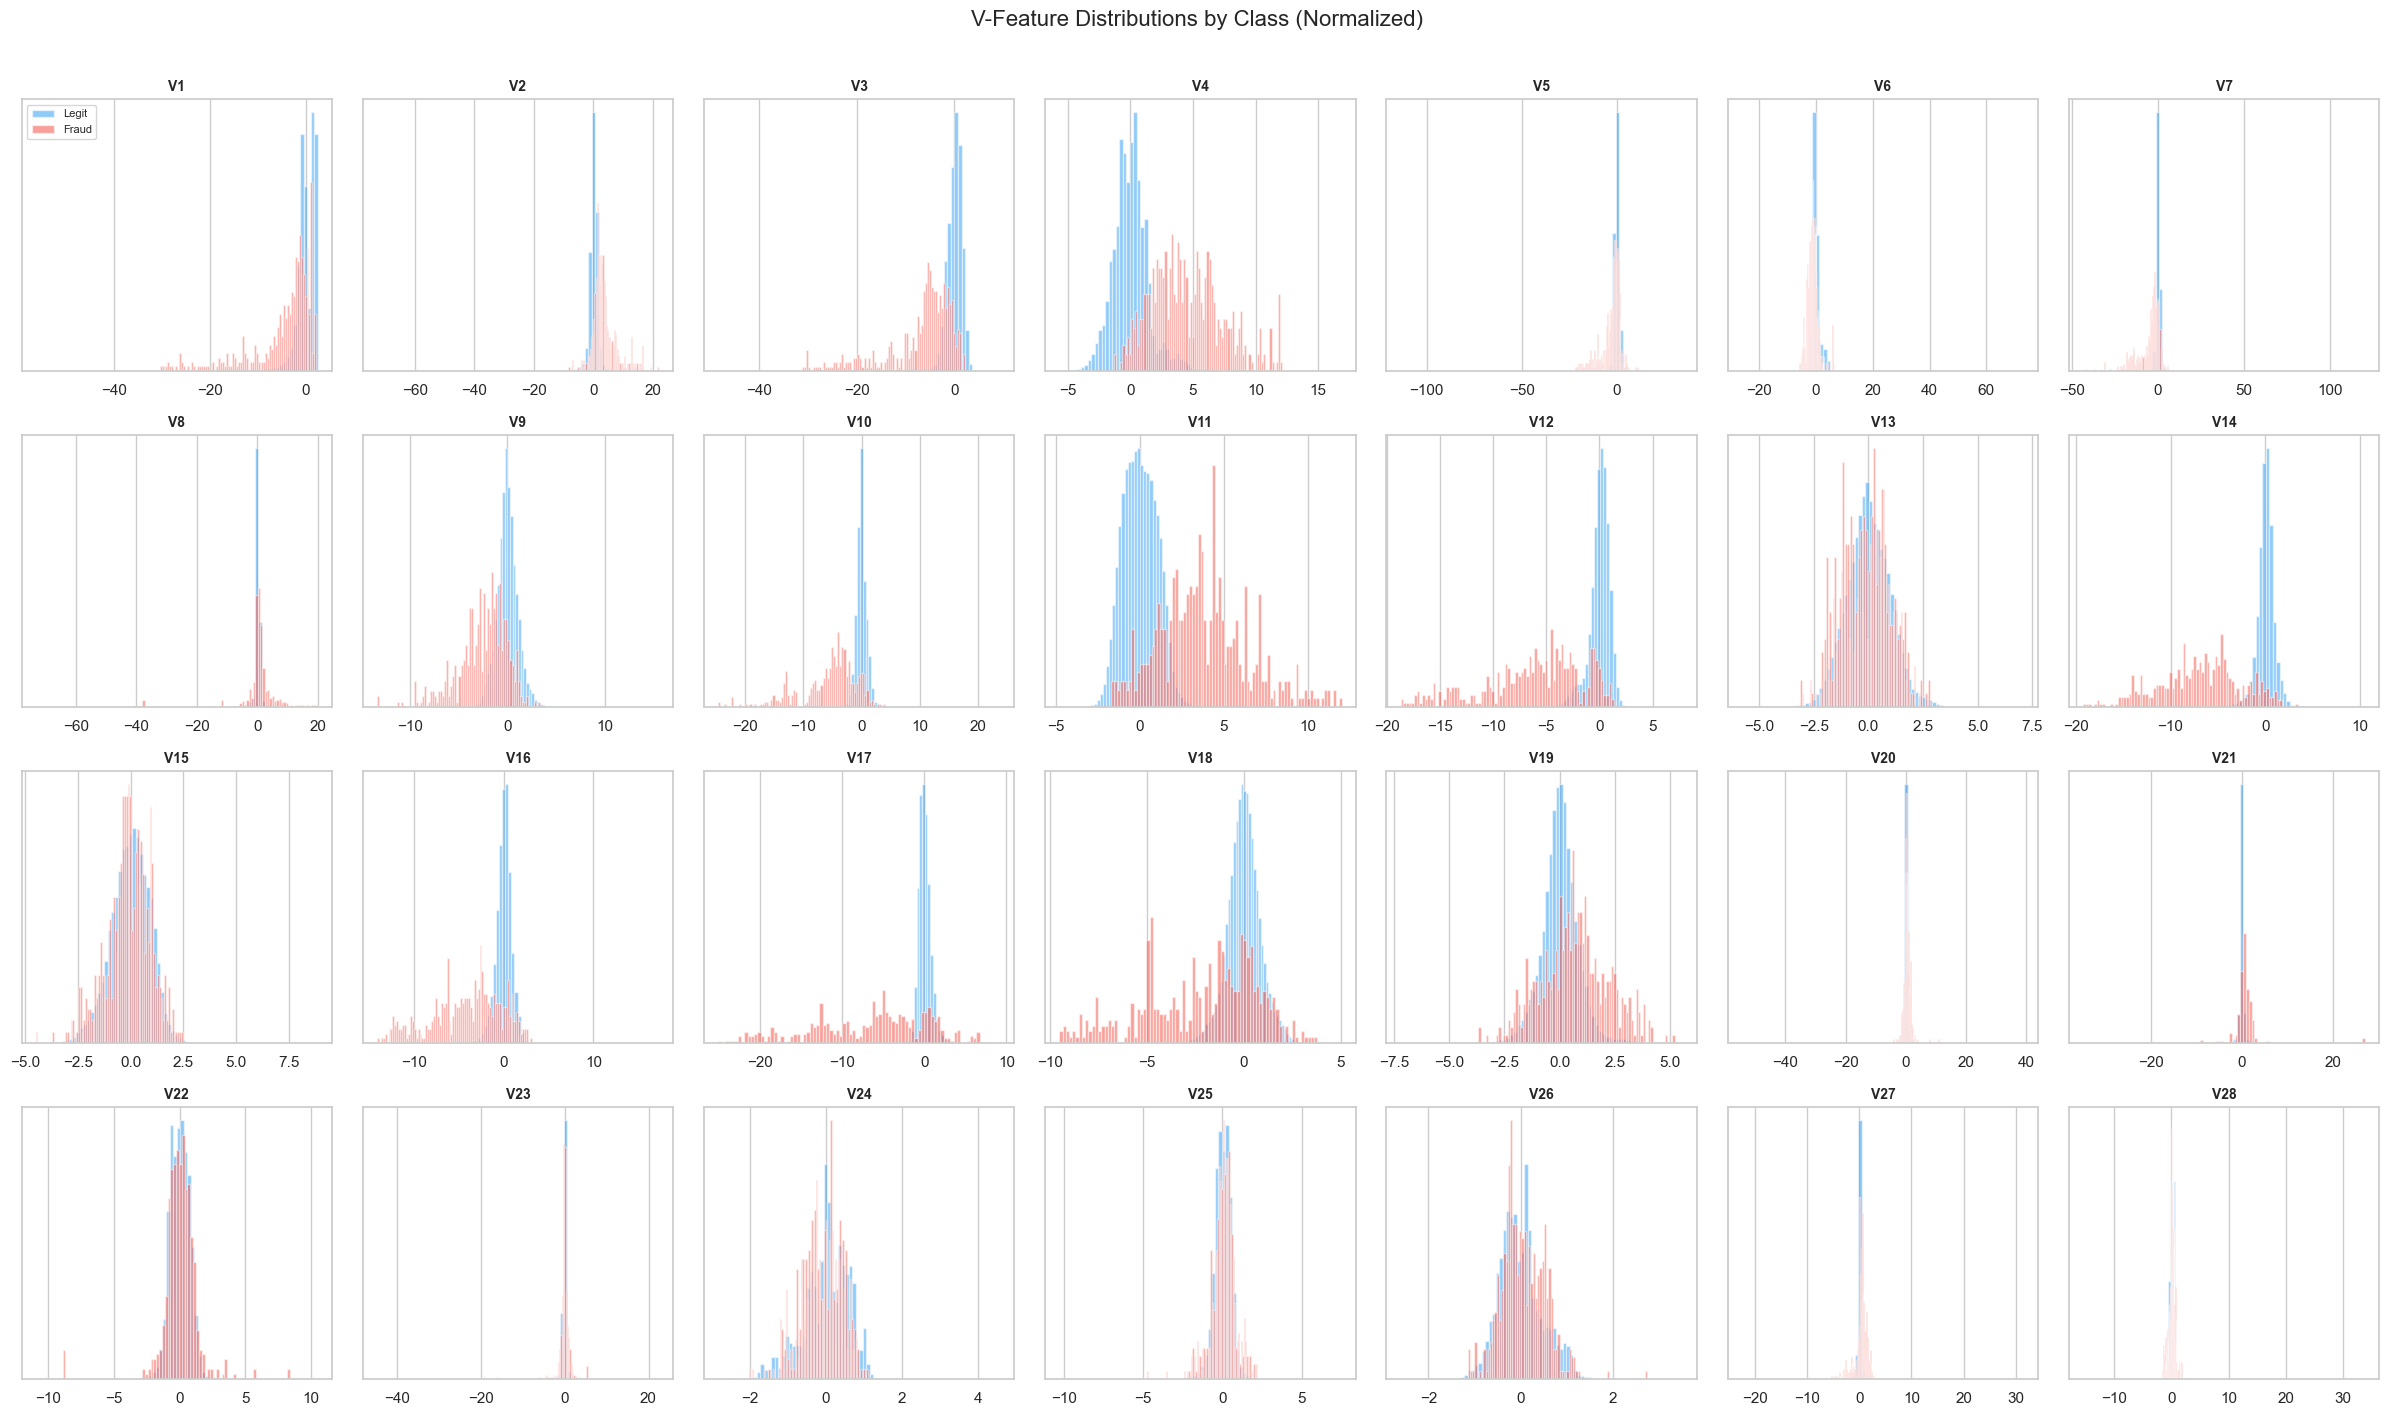

In [10]:
v_features = [f"V{i}" for i in range(1, 29)]

fig, axes = plt.subplots(4, 7, figsize=(24, 14))
axes = axes.flatten()

for i, feat in enumerate(v_features):
    ax = axes[i]
    for cls, color, label in [(0, "#2196F3", "Legit"), (1, "#F44336", "Fraud")]:
        subset = df[df["Class"] == cls][feat]
        ax.hist(subset, bins=80, color=color, alpha=0.5, label=label, density=True)
    ax.set_title(feat, fontsize=10, fontweight="bold")
    ax.set_yticks([])
    if i == 0:
        ax.legend(fontsize=8)

plt.suptitle("V-Feature Distributions by Class (Normalized)", fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig("../data/processed/01_v_features_distributions.png", bbox_inches="tight")
plt.show()

Several V-features show clear separation between fraud and legitimate distributions:
- **Strong separators:** V4, V11, V12, V14, V17 — fraud distributions are visibly shifted
- **Weak/no separation:** V8, V13, V15, V22, V23, V24, V25, V26

This confirms the correlation analysis and gives us confidence about which features
will drive model predictions.

## 4. Correlation Analysis

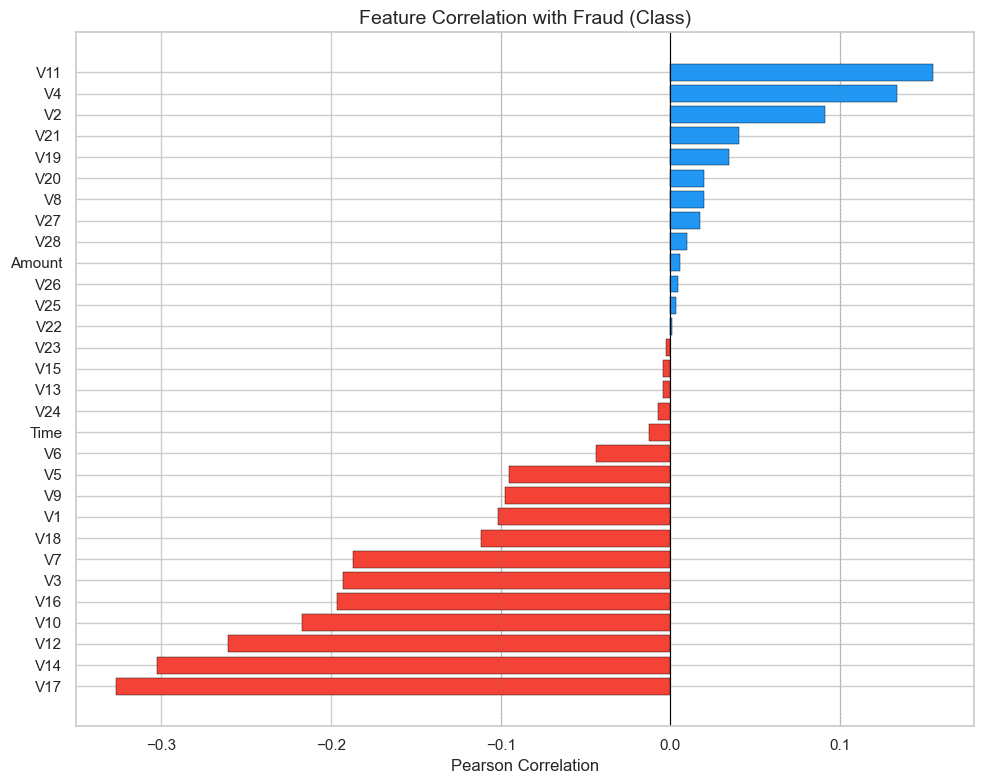

In [11]:
# Correlation with target
corr_with_target = df.corr()["Class"].drop("Class").sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#F44336" if v < 0 else "#2196F3" for v in corr_with_target.values]
ax.barh(
    corr_with_target.index,
    corr_with_target.values,
    color=colors,
    edgecolor="black",
    linewidth=0.3,
)
ax.set_title("Feature Correlation with Fraud (Class)", fontsize=14)
ax.set_xlabel("Pearson Correlation")
ax.axvline(x=0, color="black", linewidth=0.8)
# Highlight strong correlations
ax.axvline(x=0.1, color="gray", linewidth=0.5, linestyle="--", alpha=0.5)
ax.axvline(x=-0.1, color="gray", linewidth=0.5, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("../data/processed/01_correlation_with_target.png", bbox_inches="tight")
plt.show()

### Feature Correlation Heatmap (Top Features)

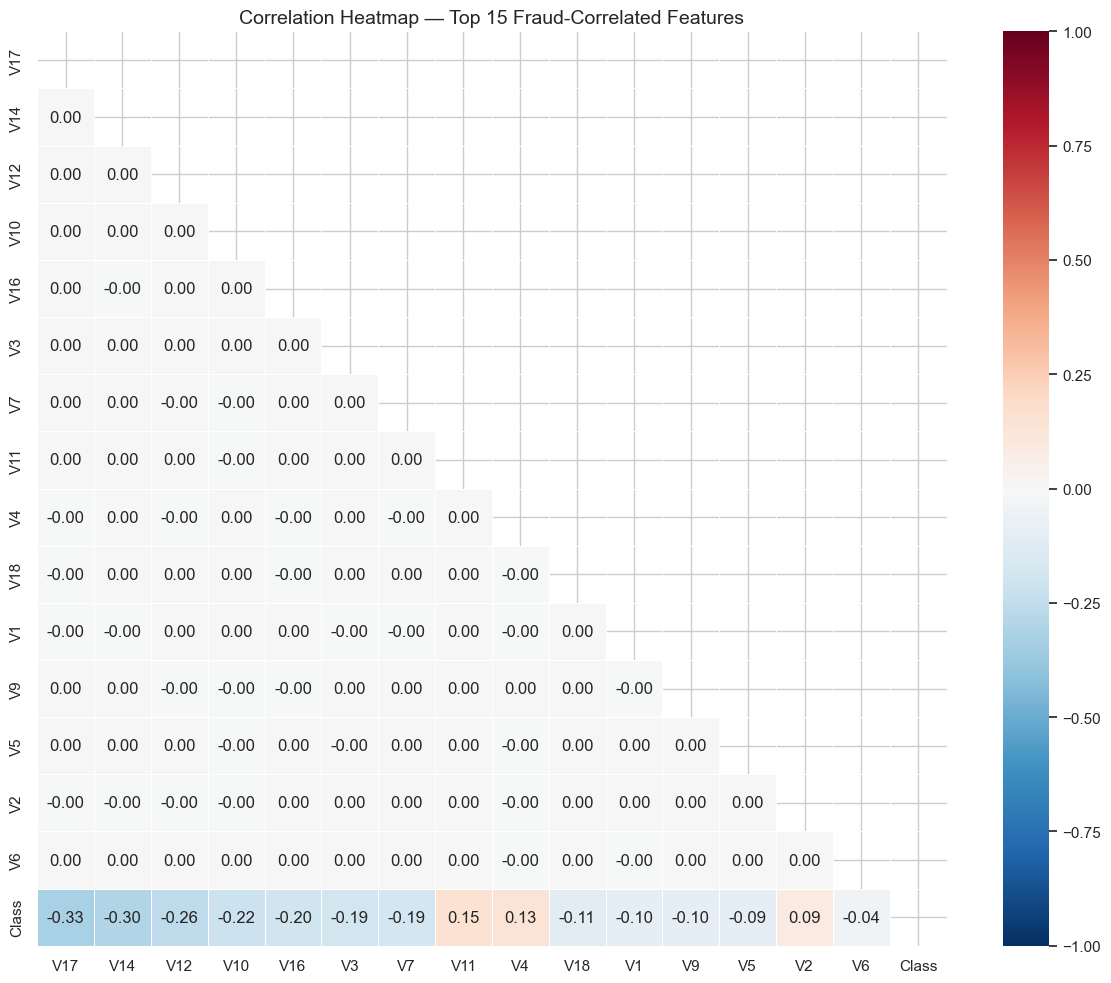

In [12]:
# Select features with strongest fraud correlations for a focused heatmap
top_features = (
    corr_with_target.abs().sort_values(ascending=False).head(15).index.tolist()
)
top_features.append("Class")

corr_matrix = df[top_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Correlation Heatmap — Top 15 Fraud-Correlated Features", fontsize=14)
plt.tight_layout()
plt.savefig("../data/processed/01_correlation_heatmap.png", bbox_inches="tight")
plt.show()

Key observations:
- PCA features are **mostly uncorrelated with each other** (by design)
- Strongest negative correlations with fraud: V17 (-0.33), V14 (-0.30), V12 (-0.26)
- Strongest positive correlations with fraud: V11 (+0.15), V4 (+0.13), V2 (+0.09)
- Amount has negligible correlation with fraud (0.006)
- The low inter-feature correlation means tree-based models should perform well
  without multicollinearity concerns

## 5. Outlier Analysis

In [13]:
# Check for extreme outliers in key features using IQR method
print("Features with extreme outliers (values > 10x IQR beyond Q3):\n")
for feat in v_features + ["Amount"]:
    q1 = df[feat].quantile(0.25)
    q3 = df[feat].quantile(0.75)
    iqr = q3 - q1
    extreme_threshold = q3 + 10 * iqr
    n_extreme = (df[feat] > extreme_threshold).sum()
    if n_extreme > 0:
        print(
            f"  {feat}: {n_extreme} extreme outliers (threshold: {extreme_threshold:.2f})"
        )

Features with extreme outliers (values > 10x IQR beyond Q3):

  V2: 20 extreme outliers (threshold: 14.83)
  V4: 2 extreme outliers (threshold: 16.66)
  V5: 67 extreme outliers (threshold: 13.65)
  V6: 35 extreme outliers (threshold: 12.07)
  V7: 127 extreme outliers (threshold: 11.82)
  V8: 341 extreme outliers (threshold: 5.69)
  V9: 1 extreme outliers (threshold: 13.00)
  V10: 171 extreme outliers (threshold: 10.35)
  V14: 1 extreme outliers (threshold: 9.68)
  V16: 1 extreme outliers (threshold: 10.44)
  V17: 1 extreme outliers (threshold: 9.23)
  V20: 1119 extreme outliers (threshold: 3.58)
  V21: 840 extreme outliers (threshold: 4.33)
  V23: 658 extreme outliers (threshold: 3.24)
  V25: 1 extreme outliers (threshold: 7.03)
  V27: 914 extreme outliers (threshold: 1.71)
  V28: 555 extreme outliers (threshold: 1.39)
  Amount: 4582 extreme outliers (threshold: 792.81)


Some V-features have extreme outliers. Since we're using tree-based models
(XGBoost, LightGBM, CatBoost), they're inherently robust to outliers — no need
to clip or remove them.

## 6. Fraud Transaction Deep Dive

In [14]:
fraud = df[df["Class"] == 1]
legit = df[df["Class"] == 0]

print(f"Fraud transactions: {len(fraud)}")
print(f"Legitimate transactions: {len(legit):,}")
print()

# Statistical comparison for top features
comparison_features = ["V17", "V14", "V12", "V10", "V11", "V4", "V2", "Amount", "Time"]
comparison = pd.DataFrame(
    {
        "Feature": comparison_features,
        "Fraud Mean": [fraud[f].mean() for f in comparison_features],
        "Legit Mean": [legit[f].mean() for f in comparison_features],
        "Fraud Std": [fraud[f].std() for f in comparison_features],
        "Legit Std": [legit[f].std() for f in comparison_features],
    }
)
comparison["Mean Diff"] = comparison["Fraud Mean"] - comparison["Legit Mean"]
comparison = comparison.sort_values("Mean Diff", key=abs, ascending=False)
print(comparison.to_string(index=False))

Fraud transactions: 492
Legitimate transactions: 284,315

Feature   Fraud Mean   Legit Mean    Fraud Std    Legit Std     Mean Diff
   Time 80746.806911 94838.202258 47835.365138 47484.015786 -14091.395347
 Amount   122.211321    88.291022   256.683288   250.105092     33.920299
    V14    -6.971723     0.012064     4.278940     0.897007     -6.983787
    V17    -6.665836     0.011535     6.970618     0.749457     -6.677371
    V12    -6.259393     0.010832     4.654458     0.945939     -6.270225
    V10    -5.676883     0.009824     4.897341     1.044204     -5.686707
     V4     4.542029    -0.007860     2.873318     1.399333      4.549889
    V11     3.800173    -0.006576     2.678605     1.003112      3.806749
     V2     3.623778    -0.006271     4.291216     1.636146      3.630049


## 7. Summary & Modeling Implications

### Dataset Characteristics
| Property | Value |
|---|---|
| Rows | 284,807 |
| Features | 30 (28 PCA + Time + Amount) |
| Target | Binary (0 = Legitimate, 1 = Fraud) |
| Fraud rate | 0.173% (492 / 284,807) |
| Missing values | 0 |
| Duplicates | 1,081 (kept — likely real) |

### Key Findings
1. **Extreme class imbalance** (1:578) — must use appropriate metrics and balancing
2. **No missing values** — no imputation needed
3. **PCA features are uncorrelated** — good for tree-based models
4. **Strong fraud signals** in V17, V14, V12, V10, V11, V4
5. **Amount** has weak direct correlation but different distributions by class
6. **Time** shows daily cycles; fraud is more uniformly distributed
7. **Outliers present** but tree-based models handle them natively

### Modeling Strategy
- **Metrics:** PR-AUC (primary), F1, precision, recall, ROC-AUC
- **Class balancing:** `scale_pos_weight` parameter in boosting models + threshold tuning
- **Feature engineering:**
  - Log-transform Amount
  - Hour-of-day from Time (cyclical encoding)
  - Standardize Amount (V-features are already standardized from PCA)
- **Models:** XGBoost, LightGBM, CatBoost — all handle imbalanced data and outliers well
- **Validation:** Stratified K-Fold to preserve class ratio in each fold